# Marine 48h Forecast — RevIN-iTransformer Ablation (18 "good" parameters)

Tests [RevIN: Reversible Instance Normalization for Accurate Time-Series Forecasting against
Distribution Shift](https://openreview.net/forum?id=cGDAkQo1C0p) (Kim et al., ICLR 2022) against the
existing iTransformer baseline, restricted to the 18 parameters iTransformer already handles well.

**Why this ablation is different from the Dual-Channel and SOFTS ablations (both reverted):** those
changed the *architecture* (added a temporal branch / replaced attention with MLP pooling) and both
lost. This changes exactly one thing — **normalization strategy** — with the architecture held
identical: same embed → attention → head iTransformer, same training loop, same data, same split.

**The motivating finding** (from the TSGym/TSCOMP component-level benchmark of MTSF methods):
*"Series Normalization proves universally effective, with RevIN and Stationary achieving the lowest
MSE across diverse datasets"* — the single most consistently effective component across 28+
architectures and 14 datasets, more reliable than any specific backbone choice.

**The mechanism:** the existing baseline normalizes the *entire training set once* (a single global
mean/std computed from all 28 days, applied to every window identically). RevIN instead normalizes
**each input window by its own local mean/std**, runs the model on that locally-normalized window, and
**reverses** the normalization on the output (multiplying back by the same window's std, adding back
its mean) — plus a small learnable per-channel affine scale/bias for flexibility. This lets the model
adapt to each window's local level/scale instead of assuming the whole 28-day history is uniformly
representative.

Standalone — does not modify any other notebook, dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]
print(f"This ablation covers the {len(GOOD_PARAMS)} 'good' parameters only: {GOOD_PARAMS}")

This ablation covers the 21 'good' parameters only: ['airTemperature', 'airPressure', 'relativeHumidity', 'dewPointTemperature', 'windSpeed', 'globalRadiation', 'currentSpeed', 'tideLevel', 'waterTemperature', 'conductivity', 'salinity', 'significantWaveHeight', 'significantWavePeriod', 'peakWaveEnergyPeriod', 'zeroCrossingPeriod', 'windDirection_sin', 'windDirection_cos', 'currentDirection_sin', 'currentDirection_cos', 'compass_sin', 'compass_cos']


## 2. Train/test split, duplicate reconstruction fit
Calendar features (`hour_sin/cos`, `dom_sin/cos`) are already bounded in [-1, 1] and are fed to both models unscaled. `GOOD_PARAMS` are kept in **raw units** here — the baseline applies its own global static z-score internally; RevIN applies its own per-instance normalization internally — so each model's normalization strategy is the only thing that differs.

In [3]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

train_df = df_num_full.iloc[:-HORIZON].copy()
test_df = df_num_full.iloc[-HORIZON:].copy()
global_mean = train_df[GOOD_PARAMS].mean()
global_std = train_df[GOOD_PARAMS].std().replace(0, 1)   # used by the baseline's data scaling AND as a
                                                           # fixed per-channel loss weight for RevIN, so
                                                           # both models train under the same effective
                                                           # cross-channel loss balance.

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")

recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))

Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


## 3. Shared windowing and training loop

In [4]:
def make_raw_windows(df, target_cols, calendar_cols, lookback, horizon):
    tgt = df[target_cols].values.astype(np.float32)
    cal = df[calendar_cols].values.astype(np.float32)
    X_tgt, X_cal, Y = [], [], []
    for origin in range(lookback, len(df) - horizon):
        X_tgt.append(tgt[origin - lookback:origin])
        X_cal.append(cal[origin - lookback:origin])
        Y.append(tgt[origin:origin + horizon])
    return (np.array(X_tgt, dtype=np.float32), np.array(X_cal, dtype=np.float32),
            np.array(Y, dtype=np.float32))

Xt, Xc, Yt = make_raw_windows(train_df, GOOD_PARAMS, calendar_cols, LOOKBACK, HORIZON)
Xt_t, Xc_t, Yt_t = torch.from_numpy(Xt), torch.from_numpy(Xc), torch.from_numpy(Yt)
n_val = max(1, int(0.1 * len(Xt_t)))
Xt_tr, Xc_tr, Y_tr = Xt_t[:-n_val], Xc_t[:-n_val], Yt_t[:-n_val]
Xt_val, Xc_val, Y_val = Xt_t[-n_val:], Xc_t[-n_val:], Yt_t[-n_val:]

last_target_window = torch.from_numpy(train_df[GOOD_PARAMS].values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
last_calendar_window = torch.from_numpy(train_df[calendar_cols].values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
global_std_t = torch.from_numpy(global_std.values.astype(np.float32))
global_mean_t = torch.from_numpy(global_mean.values.astype(np.float32))


def train_weighted(model, forward_fn, Xt_tr, Xc_tr, Y_tr, Xt_val, Xc_val, Y_val,
                    epochs=150, batch_size=64, lr=1e-3, patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)

    def weighted_mse(pred_real, actual_real):
        return ((pred_real - actual_real) / global_std_t).pow(2).mean()

    best_val, best_state, wait = float("inf"), None, 0
    n = len(Xt_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xt_b, xc_b, y_b = Xt_tr[b].to(device), Xc_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            pred = forward_fn(model, xt_b, xc_b)
            loss = weighted_mse(pred, y_b)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = weighted_mse(forward_fn(model, Xt_val.to(device), Xc_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.5f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-6:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:14s} best_val_loss={best_val:.5f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

## 4. Model A — Baseline iTransformer (global static z-score, unchanged architecture)

In [5]:
class ITransformerStatic(nn.Module):
    def __init__(self, lookback, n_target, n_calendar, horizon, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        n_total = n_target + n_calendar
        self.n_target = n_target
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_total, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x_target_scaled, x_calendar):
        x = torch.cat([x_target_scaled, x_calendar], dim=-1)
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, :self.n_target]

baseline = ITransformerStatic(LOOKBACK, len(GOOD_PARAMS), len(calendar_cols), HORIZON,
                               d_model=64, n_heads=4, n_layers=2)

def baseline_forward(model, xt_raw, xc):
    xt_scaled = (xt_raw - global_mean_t) / global_std_t
    pred_scaled = model(xt_scaled, xc)
    return pred_scaled * global_std_t + global_mean_t   # denormalize to real units for the weighted loss

baseline = train_weighted(baseline, baseline_forward, Xt_tr, Xc_tr, Y_tr, Xt_val, Xc_val, Y_val,
                           epochs=150, patience=20, name="Baseline-iTransformer")

with torch.no_grad():
    baseline_preds_real = baseline_forward(baseline, last_target_window.to(device),
                                            last_calendar_window.to(device))[0].cpu().numpy()
baseline_pred_df = pd.DataFrame(baseline_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("Baseline iTransformer 48h forecast complete.")

  [Baseline-iTransformer] epoch   1/150  val_loss=0.42493  epoch_time=0.8s  elapsed=1s


  [Baseline-iTransformer] epoch   2/150  val_loss=0.28491  epoch_time=0.7s  elapsed=2s


  [Baseline-iTransformer] epoch   3/150  val_loss=0.19863  epoch_time=0.8s  elapsed=2s


  [Baseline-iTransformer] epoch   4/150  val_loss=0.16332  epoch_time=0.8s  elapsed=3s


  [Baseline-iTransformer] epoch   5/150  val_loss=0.13950  epoch_time=0.7s  elapsed=4s


...

  [Baseline-iTransformer] epoch 147/150  val_loss=0.03504  epoch_time=0.9s  elapsed=117s


  [Baseline-iTransformer] epoch 148/150  val_loss=0.03505  epoch_time=0.8s  elapsed=118s


  [Baseline-iTransformer] epoch 149/150  val_loss=0.03500  epoch_time=0.8s  elapsed=118s


  [Baseline-iTransformer] epoch 150/150  val_loss=0.03492  epoch_time=0.8s  elapsed=119s


Baseline-iTransformer best_val_loss=0.03492  epochs_run=150  time=119.2s
Baseline iTransformer 48h forecast complete.


## 5. Model B — RevIN-iTransformer (per-instance normalization, identical architecture otherwise)

In [6]:
class RevIN(nn.Module):
    def __init__(self, n_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(n_features))
        self.affine_bias = nn.Parameter(torch.zeros(n_features))

    def normalize(self, x):                              # x: (B, lookback, n_features), raw units
        mean = x.mean(dim=1, keepdim=True)
        std = x.std(dim=1, keepdim=True) + self.eps
        x_norm = (x - mean) / std
        x_norm = x_norm * self.affine_weight + self.affine_bias
        return x_norm, mean, std

    def denormalize(self, y, mean, std):                  # y: (B, horizon, n_features)
        y = (y - self.affine_bias) / self.affine_weight
        return y * std + mean


class ITransformerRevIN(nn.Module):
    def __init__(self, lookback, n_target, n_calendar, horizon, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        n_total = n_target + n_calendar
        self.n_target = n_target
        self.revin = RevIN(n_target)
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_total, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x_target_raw, x_calendar):
        x_norm, mean, std = self.revin.normalize(x_target_raw)   # per-instance, not global
        x = torch.cat([x_norm, x_calendar], dim=-1)
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        out_target_norm = out.transpose(1, 2)[:, :, :self.n_target]
        return self.revin.denormalize(out_target_norm, mean, std)   # real units directly

revin_model = ITransformerRevIN(LOOKBACK, len(GOOD_PARAMS), len(calendar_cols), HORIZON,
                                 d_model=64, n_heads=4, n_layers=2)

def revin_forward(model, xt_raw, xc):
    return model(xt_raw, xc)   # already denormalized to real units internally

revin_model = train_weighted(revin_model, revin_forward, Xt_tr, Xc_tr, Y_tr, Xt_val, Xc_val, Y_val,
                              epochs=150, patience=20, name="RevIN-iTransformer")

with torch.no_grad():
    revin_preds_real = revin_forward(revin_model, last_target_window.to(device),
                                      last_calendar_window.to(device))[0].cpu().numpy()
revin_pred_df = pd.DataFrame(revin_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("RevIN-iTransformer 48h forecast complete.")

  [RevIN-iTransformer] epoch   1/150  val_loss=0.75892  epoch_time=0.9s  elapsed=1s


  [RevIN-iTransformer] epoch   2/150  val_loss=0.48441  epoch_time=0.8s  elapsed=2s


  [RevIN-iTransformer] epoch   3/150  val_loss=0.33035  epoch_time=0.9s  elapsed=3s


  [RevIN-iTransformer] epoch   4/150  val_loss=0.26478  epoch_time=0.9s  elapsed=3s


  [RevIN-iTransformer] epoch   5/150  val_loss=0.18192  epoch_time=0.8s  elapsed=4s


...

  [RevIN-iTransformer] epoch 140/150  val_loss=0.04282  epoch_time=0.9s  elapsed=130s


  [RevIN-iTransformer] epoch 141/150  val_loss=0.04288  epoch_time=0.9s  elapsed=130s


  [RevIN-iTransformer] epoch 142/150  val_loss=0.04266  epoch_time=0.9s  elapsed=131s


  [RevIN-iTransformer] epoch 143/150  val_loss=0.04278  epoch_time=0.9s  elapsed=132s


RevIN-iTransformer best_val_loss=0.04259  epochs_run=143  time=132.2s
RevIN-iTransformer 48h forecast complete.


## 6. The verdict: does RevIN beat global static normalization, parameter by parameter?

In [7]:
def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        if f"{ang}_sin" in out.columns:
            out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

baseline_final = reconstruct(baseline_pred_df)
revin_final = reconstruct(revin_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in GOOD_PARAMS if not c.endswith(("_sin", "_cos"))] + \
                [a for a in ["windDirection", "currentDirection", "compass"] if f"{a}_sin" in GOOD_PARAMS]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)

    yb, yr = baseline_final[p].values, revin_final[p].values
    if is_circular:
        mae_b, mae_r = circ_mae(yt, yb), circ_mae(yt, yr)
    else:
        mae_b, mae_r = mean_absolute_error(yt, yb), mean_absolute_error(yt, yr)

    skill_b = (1 - mae_b / mae_p) * 100 if mae_p > 0 else np.nan
    skill_r = (1 - mae_r / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": p, "Persistence_MAE": round(mae_p, 4),
        "iTransformer_static_MAE": round(mae_b, 4), "iTransformer_static_skill_%": round(skill_b, 1),
        "RevIN_iTransformer_MAE": round(mae_r, 4), "RevIN_iTransformer_skill_%": round(skill_r, 1),
        "improvement_pp": round(skill_r - skill_b, 1),
    })

metrics_df = pd.DataFrame(metrics).sort_values("improvement_pp", ascending=False).reset_index(drop=True)
n_improved = int((metrics_df["improvement_pp"] > 0).sum())
mean_delta = metrics_df["improvement_pp"].mean()
mean_revin = metrics_df["RevIN_iTransformer_skill_%"].mean()
mean_static = metrics_df["iTransformer_static_skill_%"].mean()
print(metrics_df.to_string(index=False))
print(f"\nRevIN improves {n_improved}/{len(metrics_df)} parameters | mean delta = {mean_delta:+.2f}pp")
print(f"Mean skill -- RevIN: {mean_revin:+.1f}%  static-normalization baseline: {mean_static:+.1f}%")
if n_improved > len(metrics_df) / 2 and mean_delta > 0:
    print("VERDICT: RevIN beats static normalization -- majority improvement, positive mean delta. Worth a dashboard.")
else:
    print("VERDICT: keep the static-normalization baseline -- no clear majority benefit from RevIN.")

            parameter  Persistence_MAE  iTransformer_static_MAE  iTransformer_static_skill_%  RevIN_iTransformer_MAE  RevIN_iTransformer_skill_%  improvement_pp
significantWavePeriod           0.3317                   0.0822                         75.2                  0.0826                        75.1            -0.1
     currentDirection          91.7282                   3.5749                         96.1                  3.6444                        96.0            -0.1
     relativeHumidity          18.7896                   0.6925                         96.3                  0.7363                        96.1            -0.2
        windDirection          73.1616                   2.2029                         97.0                  2.3326                        96.8            -0.2
   zeroCrossingPeriod           0.3066                   0.0830                         72.9                  0.0841                        72.6            -0.4
            windSpeed           2.

## 7. Plot a few parameters, baseline vs RevIN vs actual

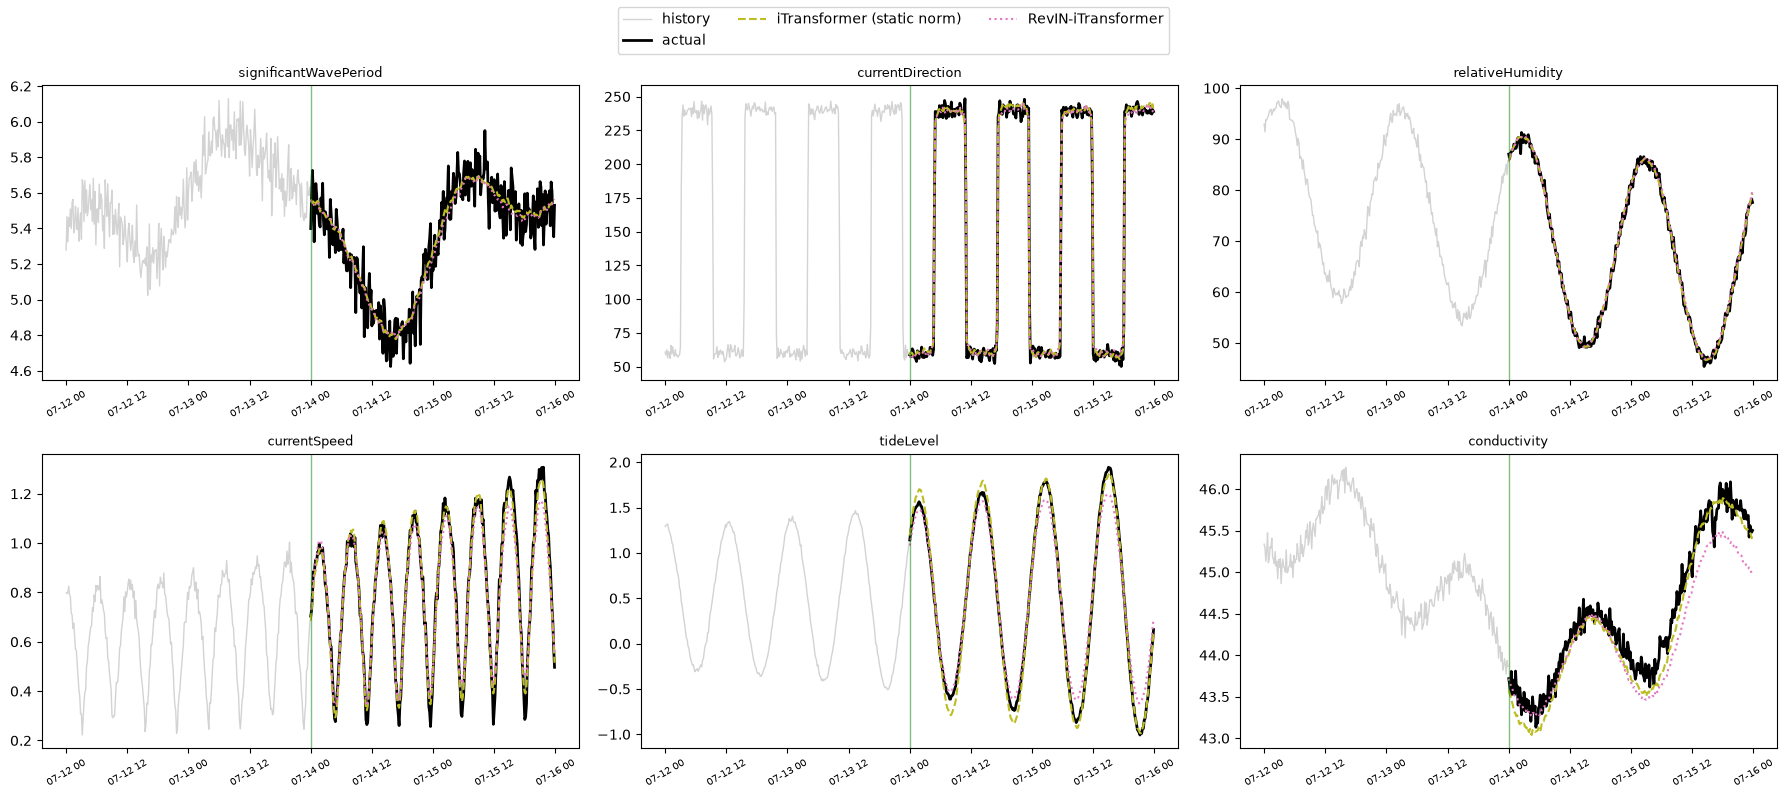

Saved revin_ablation_plot.png  (top 3 = biggest RevIN gains, bottom 3 = biggest RevIN losses)


In [8]:
plot_params = metrics_df["parameter"].head(3).tolist() + metrics_df["parameter"].tail(3).tolist()
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), plot_params):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, baseline_final[c], color="#bcbd22", lw=1.5, ls="--", label="iTransformer (static norm)")
    ax.plot(truth.index, revin_final[c], color="#e377c2", lw=1.5, ls=":", label="RevIN-iTransformer")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("revin_ablation_plot.png", dpi=110)
plt.show()
print("Saved revin_ablation_plot.png  (top 3 = biggest RevIN gains, bottom 3 = biggest RevIN losses)")

## 8. Save outputs

In [9]:
metrics_df.to_csv("metrics_revin_ablation.csv", index=False)

fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__iTransformer_static"] = baseline_final[p].values
    fva[f"{p}__RevIN_iTransformer"] = revin_final[p].values
fva.to_csv("forecast_vs_actual_revin.csv", index=False)

print("Saved: metrics_revin_ablation.csv, forecast_vs_actual_revin.csv, revin_ablation_plot.png")

Saved: metrics_revin_ablation.csv, forecast_vs_actual_revin.csv, revin_ablation_plot.png


## 9. Conclusion

Section 6 is the actual verdict. This is an ablation, not a foregone conclusion — if RevIN doesn't
improve a clear majority of the 18 "good" parameters with a positive mean delta, the honest result is
to keep the existing static-normalization iTransformer (already in production use across
`Marine_Forecast_RealEMS_iTransformer_Only.ipynb` and all 4 hybrid notebooks), the same standard
applied to the Dual-Channel and SOFTS ablations, both of which were reverted for the same reason.